In [8]:
#imports
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from TrajectoryNet import dataset

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

eb_data = dataset.EBData("pcs", max_dim=50)
data = eb_data.data
labels = eb_data.get_times()

# normalize
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

X = torch.FloatTensor(data_scaled).to(device)
y = torch.LongTensor(labels).to(device)

print(f"Data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique time points: {np.unique(labels)}")

Using device: cuda
Data shape: torch.Size([16819, 50])
Labels shape: torch.Size([16819])
Unique time points: [0 1 2 3 4]


In [10]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=128, dropout=0.1):
        super(VAE, self).__init__()
        
        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_var = nn.Linear(hidden_dim, latent_dim)
        
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim)
        )
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

In [11]:
INPUT_DIM  = 50
LATENT_DIM = 10
HIDDEN_DIM = 128
DROPOUT    = 0.1
BATCH_SIZE = 256
EPOCHS     = 300
LR         = 1e-3
KL_WARMUP  = 100   # epochs to ramp beta from 0 to 1

model = VAE(INPUT_DIM, LATENT_DIM, HIDDEN_DIM, DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

dataset_torch = TensorDataset(X, y)
loader = DataLoader(dataset_torch, batch_size=BATCH_SIZE, shuffle=True)

def vae_loss(recon_x, x, mu, log_var, beta=1.0):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 51,014


In [12]:
train_losses = []
recon_losses = []
kl_losses    = []

model.train()
for epoch in range(EPOCHS):
    # KL annealing: ramp beta linearly from 0 to 1 over KL_WARMUP epochs
    beta = min(1.0, epoch / KL_WARMUP)
    
    epoch_loss  = 0
    epoch_recon = 0
    epoch_kl    = 0
    
    for batch_x, _ in loader:
        optimizer.zero_grad()
        recon, mu, log_var = model(batch_x)
        loss, recon_loss, kl_loss = vae_loss(recon, batch_x, mu, log_var, beta=beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss  += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl    += kl_loss.item()
    
    scheduler.step()
    
    avg_loss  = epoch_loss  / len(loader)
    avg_recon = epoch_recon / len(loader)
    avg_kl    = epoch_kl    / len(loader)
    
    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Beta: {beta:.2f} | "
              f"Recon: {avg_recon:.4f} | KL: {avg_kl:.4f} | Total: {avg_loss:.4f}")

print("Training complete.")

Epoch  30/300 | Beta: 0.29 | Recon: 0.7008 | KL: 0.5692 | Total: 0.8658
Epoch  60/300 | Beta: 0.59 | Recon: 0.8199 | KL: 0.2433 | Total: 0.9635
Epoch  90/300 | Beta: 0.89 | Recon: 0.9242 | KL: 0.0716 | Total: 0.9880
Epoch 120/300 | Beta: 1.00 | Recon: 0.9417 | KL: 0.0483 | Total: 0.9901
Epoch 150/300 | Beta: 1.00 | Recon: 0.9479 | KL: 0.0414 | Total: 0.9893
Epoch 180/300 | Beta: 1.00 | Recon: 0.9444 | KL: 0.0422 | Total: 0.9866
Epoch 210/300 | Beta: 1.00 | Recon: 0.9427 | KL: 0.0421 | Total: 0.9847
Epoch 240/300 | Beta: 1.00 | Recon: 0.9426 | KL: 0.0417 | Total: 0.9842
Epoch 270/300 | Beta: 1.00 | Recon: 0.9422 | KL: 0.0430 | Total: 0.9852
Epoch 300/300 | Beta: 1.00 | Recon: 0.9429 | KL: 0.0422 | Total: 0.9851
Training complete.


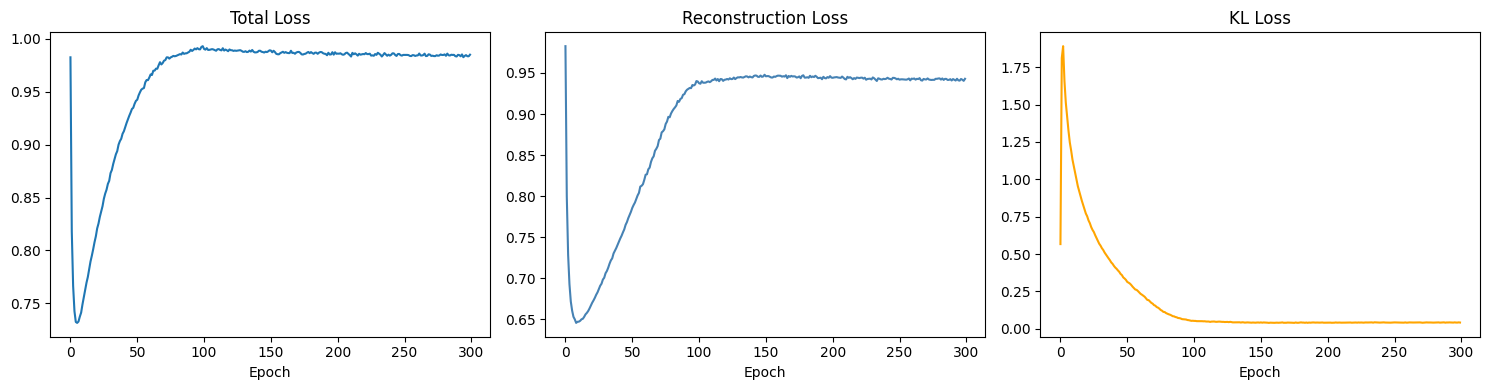

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(recon_losses, color='steelblue')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')

axes[2].plot(kl_losses, color='orange')
axes[2].set_title('KL Loss')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('../figures/02_training_curves.png', dpi=150)
plt.show()

KL per latent dimension:
  dim 0: 0.1000
  dim 1: 0.0106
  dim 2: 0.1877
  dim 3: 0.0001
  dim 4: 0.0001
  dim 5: 0.0000
  dim 6: 0.0156
  dim 7: 0.0000
  dim 8: 0.0446
  dim 9: 0.0717


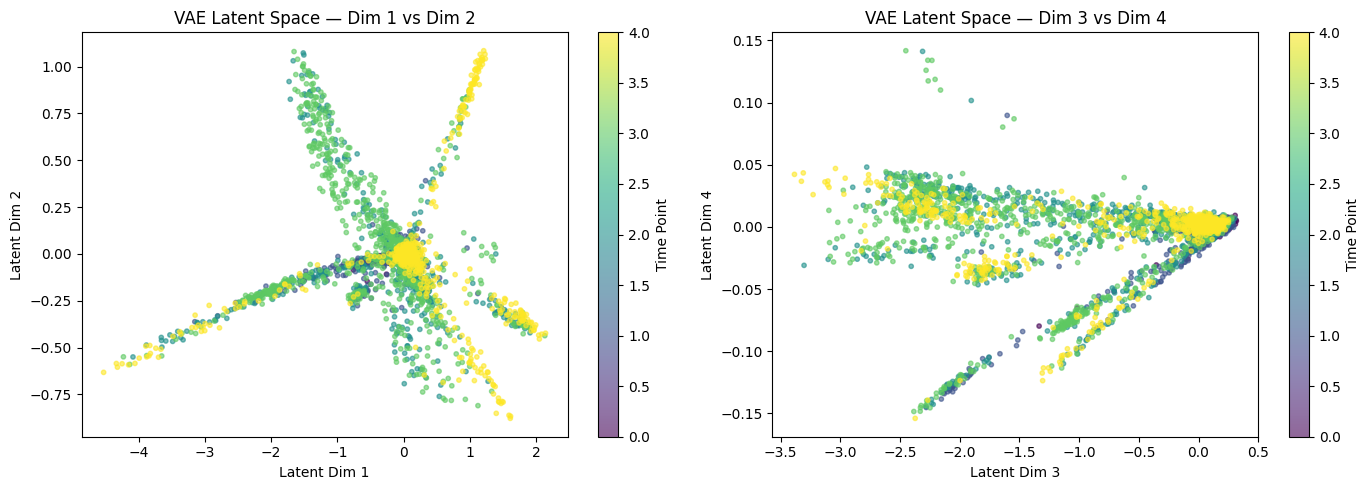

In [14]:
model.eval()
with torch.no_grad():
    mu, log_var = model.encode(X)
    Z = mu.cpu().numpy()

# check how many latent dimensions are actually being used
kl_per_dim = (-0.5 * (1 + log_var - mu.pow(2) - log_var.exp())).mean(0).cpu().numpy()
print("KL per latent dimension:")
for i, kl in enumerate(kl_per_dim):
    print(f"  dim {i}: {kl:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(Z[:, 0], Z[:, 1], c=labels, 
                          cmap='viridis', alpha=0.6, s=10)
plt.colorbar(scatter, ax=axes[0], label='Time Point')
axes[0].set_xlabel('Latent Dim 1')
axes[0].set_ylabel('Latent Dim 2')
axes[0].set_title('VAE Latent Space — Dim 1 vs Dim 2')

scatter2 = axes[1].scatter(Z[:, 2], Z[:, 3], c=labels,
                           cmap='viridis', alpha=0.6, s=10)
plt.colorbar(scatter2, ax=axes[1], label='Time Point')
axes[1].set_xlabel('Latent Dim 3')
axes[1].set_ylabel('Latent Dim 4')
axes[1].set_title('VAE Latent Space — Dim 3 vs Dim 4')

plt.tight_layout()
plt.savefig('../figures/02_vae_latent_space.png', dpi=150)
plt.show()

In [15]:
import pickle

# save model and scaler
torch.save(model.state_dict(), '../models/vae.pt')

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# identify active dimensions (KL > 0.01)
with torch.no_grad():
    mu, log_var = model.encode(X)

kl_per_dim = (-0.5 * (1 + log_var - mu.pow(2) - log_var.exp())).mean(0).cpu().numpy()
active_dims = np.where(kl_per_dim > 0.01)[0]
print(f"Active dimensions: {active_dims}")

# save full and active latent representations
Z_full = mu.cpu().numpy()
Z_active = Z_full[:, active_dims]

np.save('../data/Z_latent.npy', Z_full)
np.save('../data/Z_latent_active.npy', Z_active)
np.save('../data/active_dims.npy', active_dims)
np.save('../data/labels.npy', labels)

print(f"Full latent shape: {Z_full.shape}")
print(f"Active latent shape: {Z_active.shape}")
print("Saved: vae.pt, scaler.pkl, Z_latent.npy, Z_latent_active.npy, active_dims.npy, labels.npy")

Active dimensions: [0 1 2 6 8 9]
Full latent shape: (16819, 10)
Active latent shape: (16819, 6)
Saved: vae.pt, scaler.pkl, Z_latent.npy, Z_latent_active.npy, active_dims.npy, labels.npy
